In [1]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("fifa_eda.csv")
df.head()

,ID,Name,Age,Nationality,Overall,Potential,Club,Value,Wage,Preferred Foot,International Reputation,Skill Moves,Position,Joined,Contract Valid Until,Height,Weight,Release Clause
0,158023,L. Messi,31,Argentina,94,94,FC Barcelona,110500.0,565.0,Left,5.0,4.0,RF,2004,2021-01-01,5.583333,159.0,226500.0
1,20801,Cristiano Ronaldo,33,Portugal,94,94,Juventus,77000.0,405.0,Right,5.0,5.0,ST,2018,2022-01-01,6.166667,183.0,127100.0
2,190871,Neymar Jr,26,Brazil,92,93,Paris Saint-Germain,118500.0,290.0,Right,5.0,5.0,LW,2017,2022-01-01,5.750000,150.0,228100.0
3,193080,De Gea,27,Spain,91,93,Manchester United,72000.0,260.0,Right,4.0,1.0,GK,2011,2020-01-01,6.333333,168.0,138600.0
4,192985,K. De Bruyne,27,Belgium,91,92,Manchester City,102000.0,355.0,Right,4.0,4.0,RCM,2015,2023-01-01,5.916667,154.0,196400.0


In [3]:
df['Height'] = pd.to_numeric(df['Height'], errors='coerce')
df['Skill Moves'] = pd.to_numeric(df['Skill Moves'], errors='coerce')
df['Age'] = pd.to_numeric(df['Age'], errors='coerce')
df['Overall'] = pd.to_numeric(df['Overall'], errors='coerce')
df['Potential'] = pd.to_numeric(df['Potential'], errors='coerce')

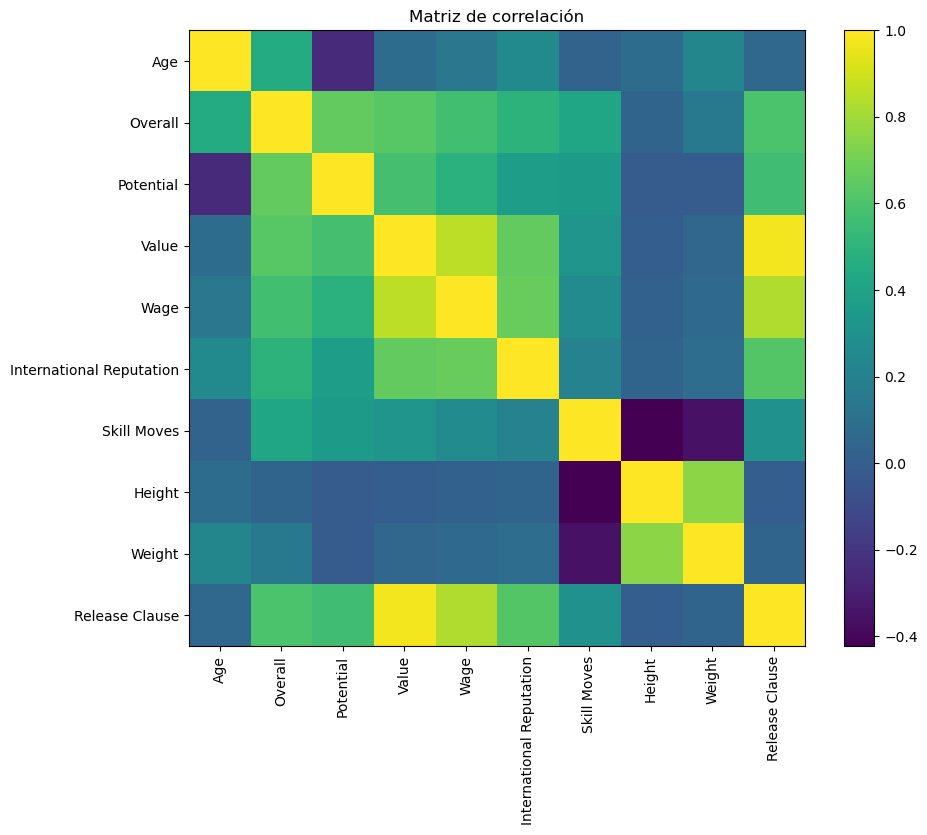

In [8]:
numeric_cols = ['Age', 'Overall', 'Potential', 'Value', 'Wage', 'International Reputation', 'Skill Moves', 'Height', 'Weight', 'Release Clause']

corr = df[numeric_cols].corr()

plt.figure(figsize=(10,8))
plt.imshow(corr)
plt.colorbar()
plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.columns)), corr.columns)
plt.title("Matriz de correlación")
plt.show()

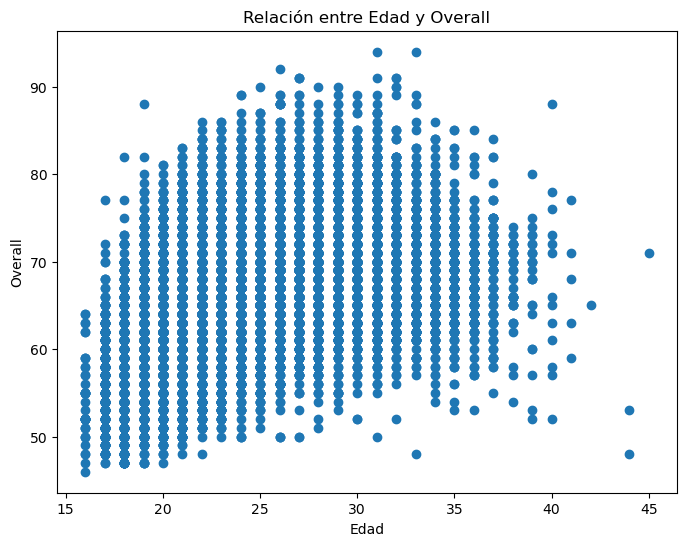

In [11]:
plt.figure(figsize=(8,6))
plt.scatter(df['Age'], df['Overall'])
plt.xlabel("Edad")
plt.ylabel("Overall")
plt.title("Relación entre Edad y Overall")
plt.show()

In [12]:
correlacion_age_overall = df['Age'].corr(df['Overall'])
print("Correlación entre Age y Overall:", correlacion_age_overall)

print("Interpretación: la relación muestra qué tanto influye la edad en el rendimiento general del jugador. Si el valor es positivo, al aumentar la edad tiende a aumentar el overall; si es negativo, tiende a disminuir.")

Correlación entre Age y Overall: 0.45234952145633556
Interpretación: la relación muestra qué tanto influye la edad en el rendimiento general del jugador. Si el valor es positivo, al aumentar la edad tiende a aumentar el overall; si es negativo, tiende a disminuir.


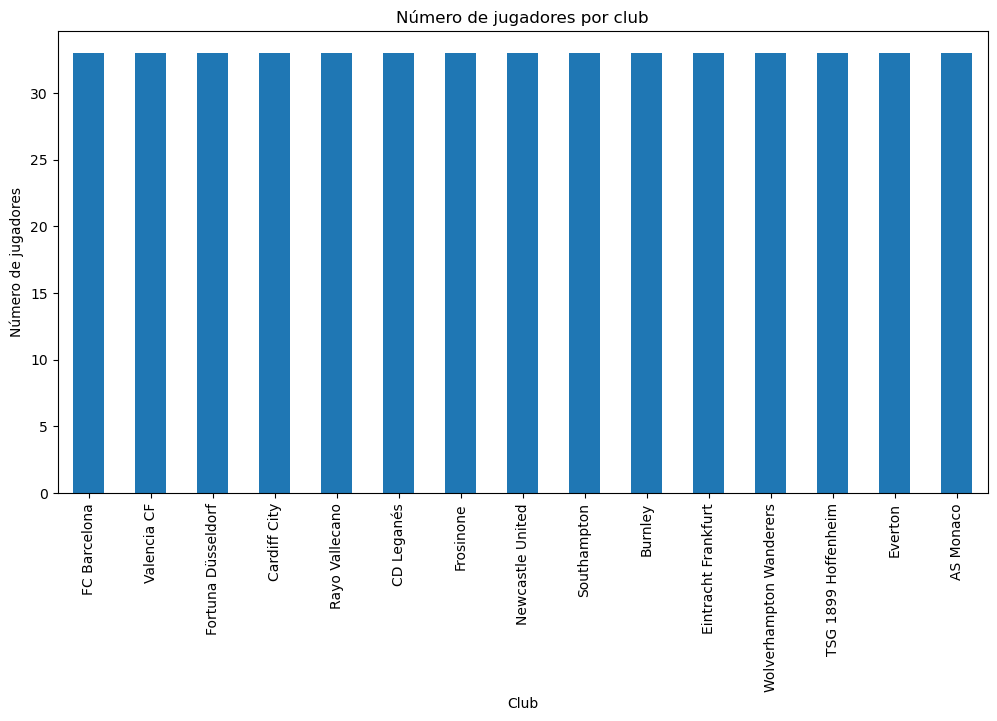

In [14]:
players_by_club = df['Club'].value_counts().head(15)

plt.figure(figsize=(12,6))
players_by_club.plot(kind='bar')
plt.xlabel("Club")
plt.ylabel("Número de jugadores")
plt.title("Número de jugadores por club")
plt.xticks(rotation=90)
plt.show()

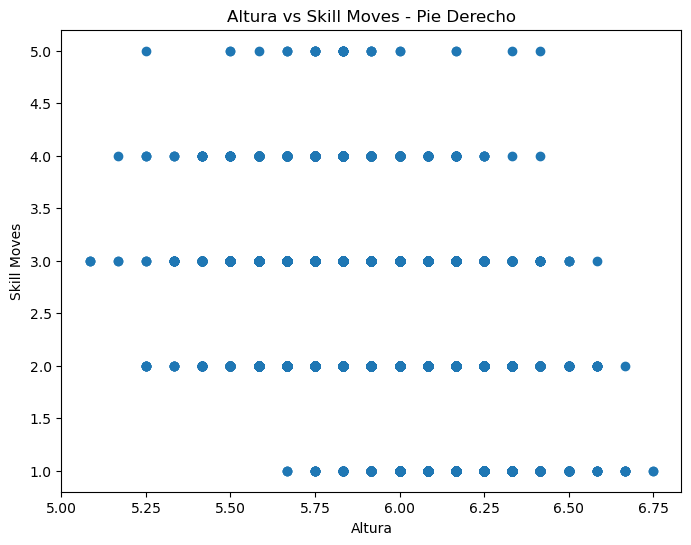

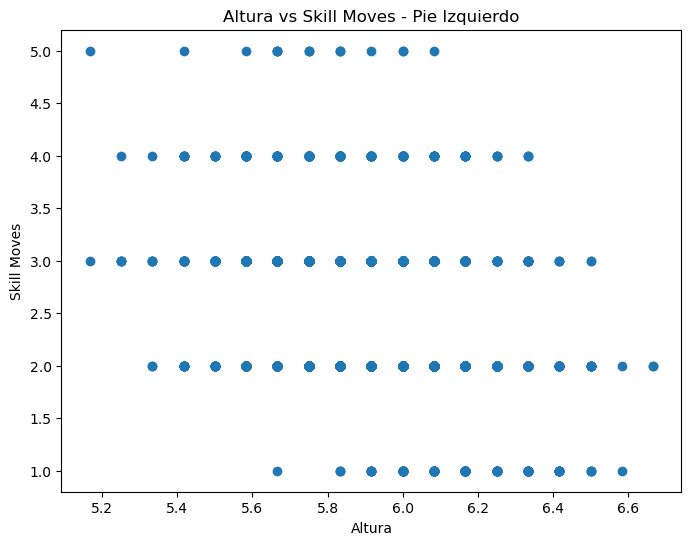

In [20]:
right_foot = df[df['Preferred Foot'] == 'Right']
left_foot = df[df['Preferred Foot'] == 'Left']

plt.figure(figsize=(8,6))
plt.scatter(right_foot['Height'], right_foot['Skill Moves'])
plt.xlabel("Altura")
plt.ylabel("Skill Moves")
plt.title("Altura vs Skill Moves - Pie Derecho")
plt.show()

plt.figure(figsize=(8,6))
plt.scatter(left_foot['Height'], left_foot['Skill Moves'])
plt.xlabel("Altura")
plt.ylabel("Skill Moves")
plt.title("Altura vs Skill Moves - Pie Izquierdo")
plt.show()

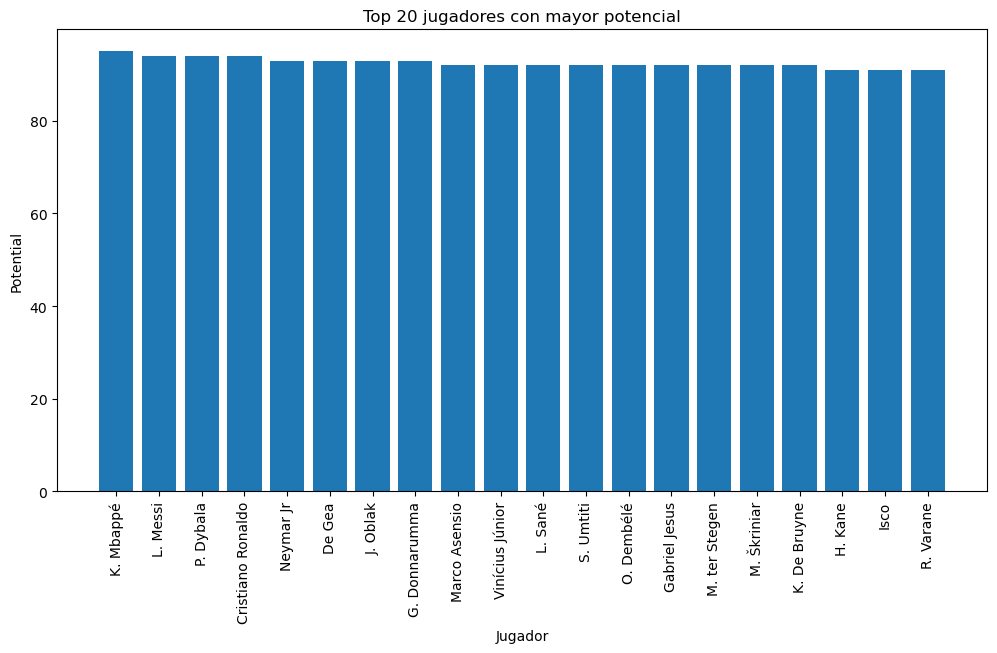

In [23]:
cracks = df[df['Potential'] >= 85].sort_values(by='Potential', ascending=False).head(20)

plt.figure(figsize=(12,6))
plt.bar(cracks['Name'], cracks['Potential'])
plt.xlabel("Jugador")
plt.ylabel("Potential")
plt.title("Top 20 jugadores con mayor potencial")
plt.xticks(rotation=90)
plt.show()

In [25]:
cracks[['Name', 'Age', 'Nationality', 'Club', 'Overall', 'Potential']]

,Name,Age,Nationality,Club,Overall,Potential
25,K. Mbappé,19,France,Paris Saint-Germain,88,95
0,L. Messi,31,Argentina,FC Barcelona,94,94
15,P. Dybala,24,Argentina,Juventus,89,94
1,Cristiano Ronaldo,33,Portugal,Juventus,94,94
2,Neymar Jr,26,Brazil,Paris Saint-Germain,92,93
3,De Gea,27,Spain,Manchester United,91,93
9,J. Oblak,25,Slovenia,Atlético Madrid,90,93
229,G. Donnarumma,19,Italy,Milan,82,93
79,Marco Asensio,22,Spain,Real Madrid,85,92
1143,Vinícius Júnior,17,Brazil,Real Madrid,77,92
